<a href="https://colab.research.google.com/github/helsach/2025_pengolahan_citra_ti2b/blob/main/Jobsheet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Helsa Christabel Harsono (4.33.23.1.10)

#JOBSHEET 03: PERBAIKAN CITRA DALAM DOMAIN SPASIAL

## Praktikum 1. Transormasi Kurva (Citra Negatif)

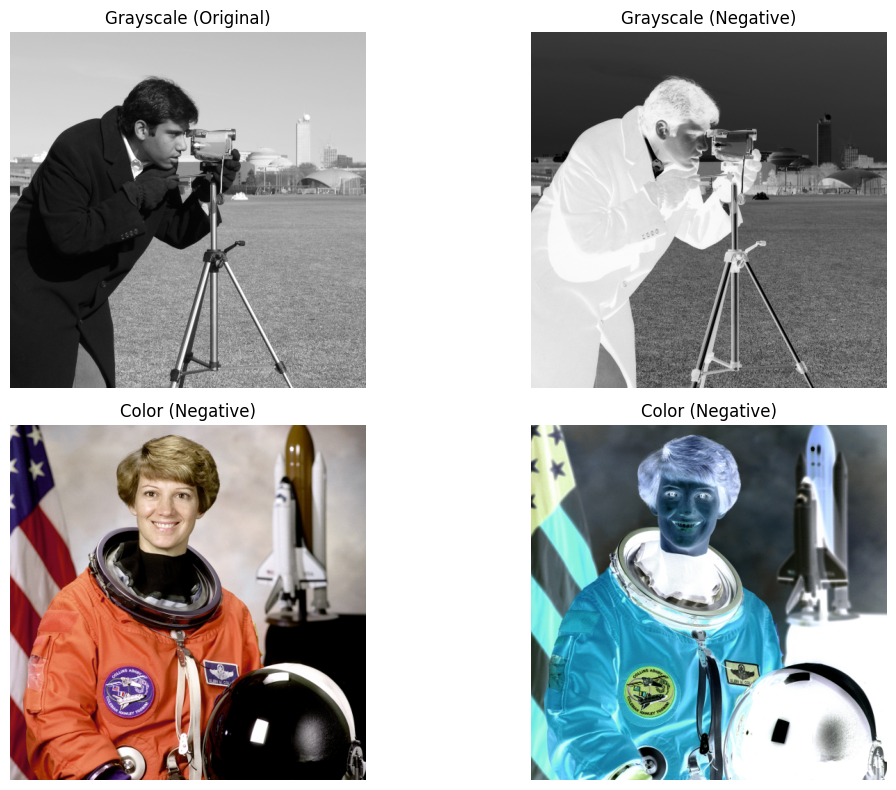

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# 1. Transformasi negatif citra grayscale
image_gray_uint8 = data.camera() # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8) # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float # Inversi intensitas: output = 1 - input

# 2. Transformasi negatif citra berwarna
image_color_uint8 = data.astronaut() # Citra berwarna (512x512, 3, 0..255)
image_color_float = img_as_float(image_color_uint8) # Konversi ke float

negative_color = 1.0 - image_color_float # Inversi intensitas tiap kanal RGB

#  3. Plotting hasil
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 4. Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title('Grayscale (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title('Grayscale (Negative)')
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title('Color (Negative)')
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title('Color (Negative)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Praktikum 2. Histogram dan Ekualisasi Histogram

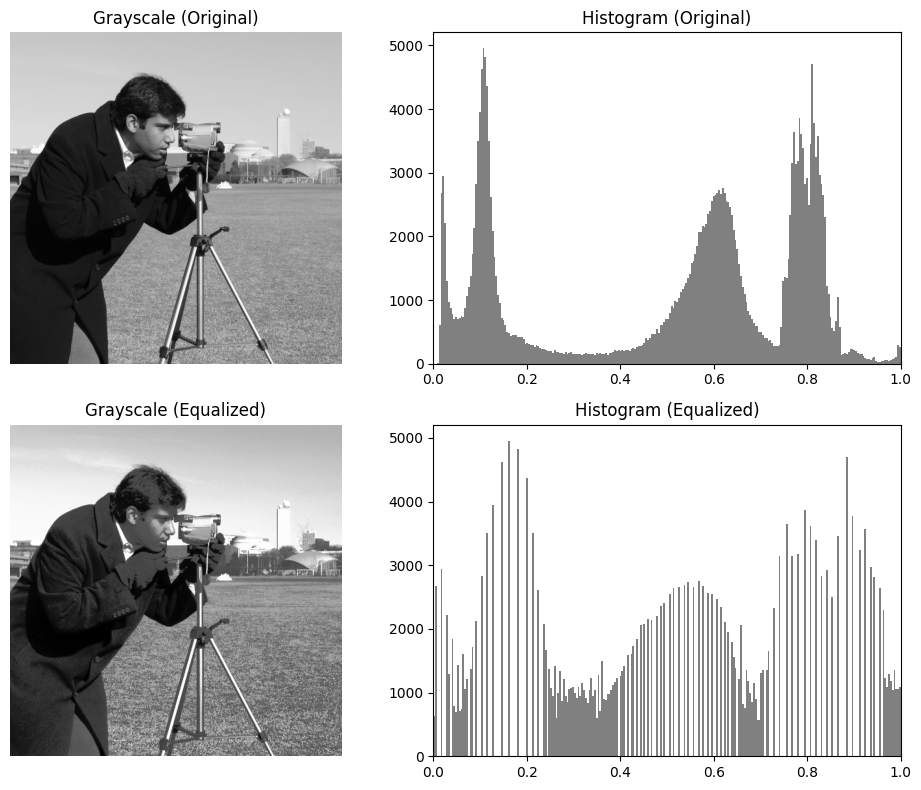

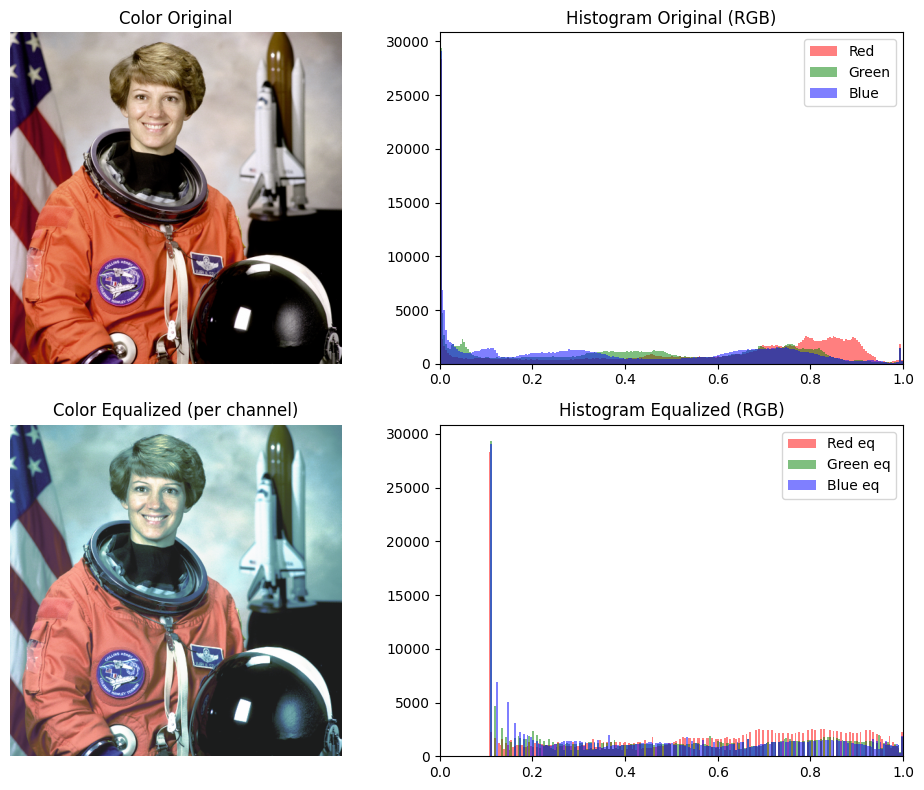

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# Bagian 1: Histogram & ekualisasi histogram (greyscale)

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)

# 2. Menghitung histogram citra asli (dengan numpy.histogram)
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra asli grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title('Grayscale (Original)')
axes[0, 0].axis('off')

# (b) Histogram citra asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram (Original)")
axes[0, 1].set_xlim(0,1)

# (c) Citra hasil ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title('Grayscale (Equalized)')
axes[1, 0].axis('off')

# (d) Histogram citra hasil ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram (Equalized)")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

# Bagian 2: Histogram & ekualisasi histogram (citra warna)

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

# 2. Kita dapat menghitung histogram gabungan (semua kanal) atau per kanal
# Di sini kita tampilkan histogram  gabungan R, G, B untuk citra asli
r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]
hist_color, bins_color = np.histogram(image_color_uint8.ravel(), bins=256, range=(0, 1))

# Hitung histogram untuk tiap kanal, 256 bins
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram tiap kanal secara independen
# dapat mengubah keseimbangan warna (terkadang lebih baik ekualisasi hanya pada kanal luminance (Y))
# atau Value (HSV). Tapi di sini kita tunjukkan contoh per kanal.)
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali untuk menghasilkan citra hasil ekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram citra berwarna ekualisasi (tiap kanal)
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

# 4. Plot citra berwarna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra asli (Color)
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title('Color Original')
axes2[0, 0].axis('off')

# (b) Histogram asli (tumpuk R, G, B)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra hasil ekuaisasi (RGB)
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title('Color Equalized (per channel)')
axes2[1, 0].axis('off')

# (d) Histogram ekualisasi (tumpuk R, G, B)
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0,1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Praktikum 3. Konvolusi (Filter Rata-rata)

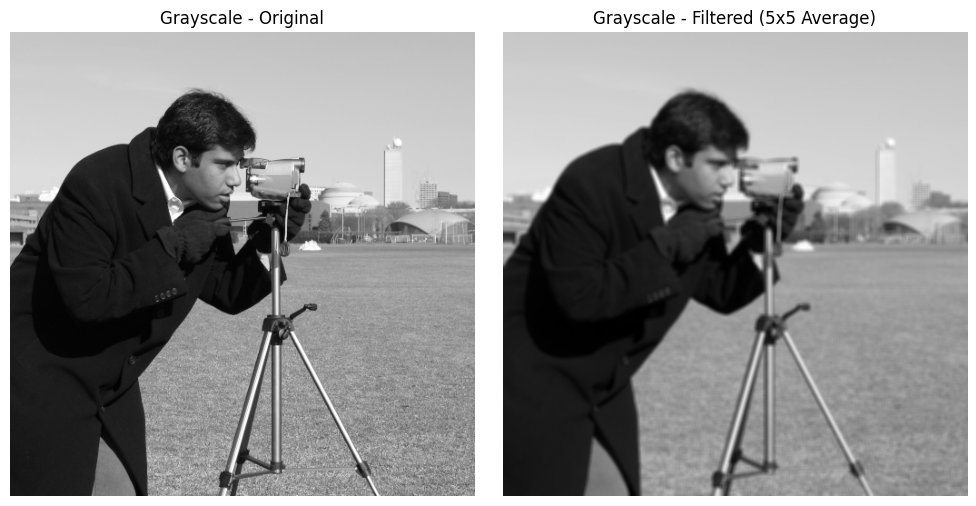

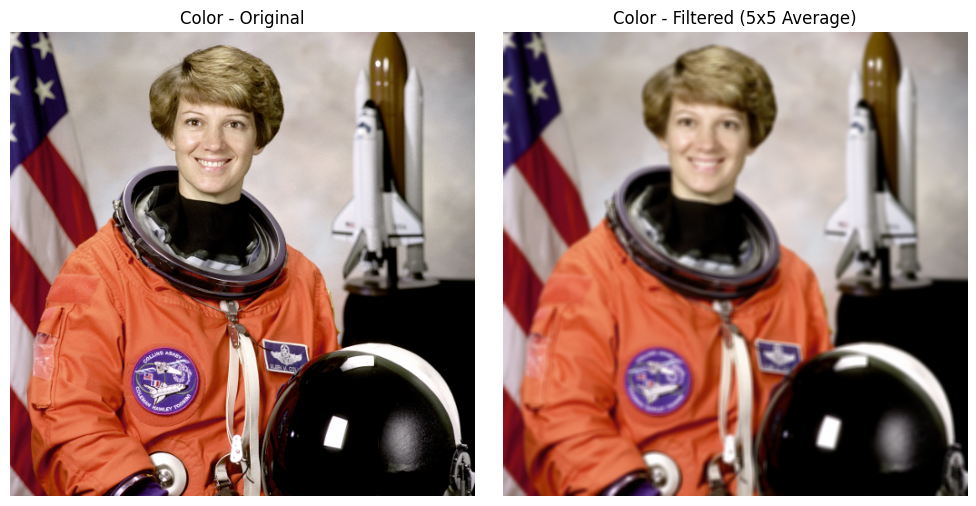

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera() # range 0..255
gray_img = img_as_float(gray_uint8)	# konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 2) FILTER RATA-RATA PADA CITRA BERWARNA

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut() # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8) # konversi float [0..1]

# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B
#	secara terpisah, lalu gabungkan.
color_filtered = np.zeros_like(color_img)

for c in range(3): # c = 0 (Red), 1 (Green), 2 (Blue)
	channel_original = color_img[:, :, c]
	channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
	color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()


## Praktikum 4. Filter Median (penghilangan noise/derau)

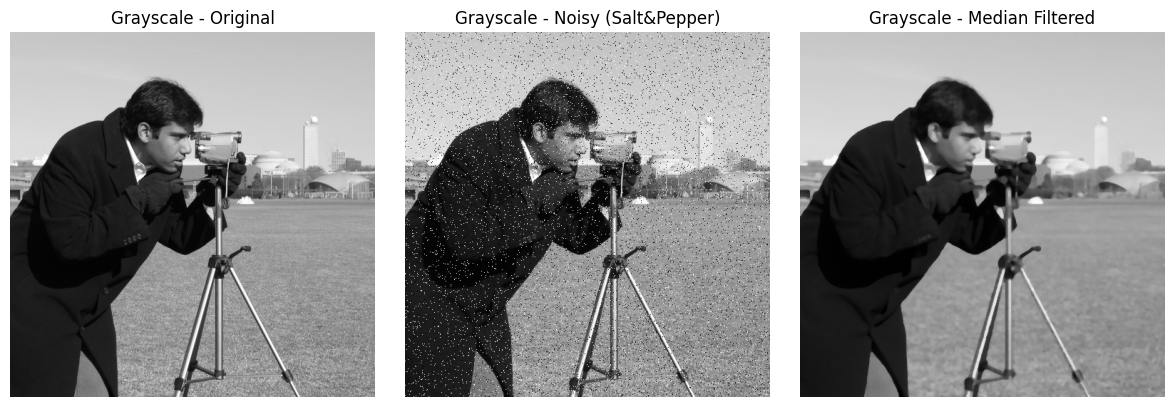

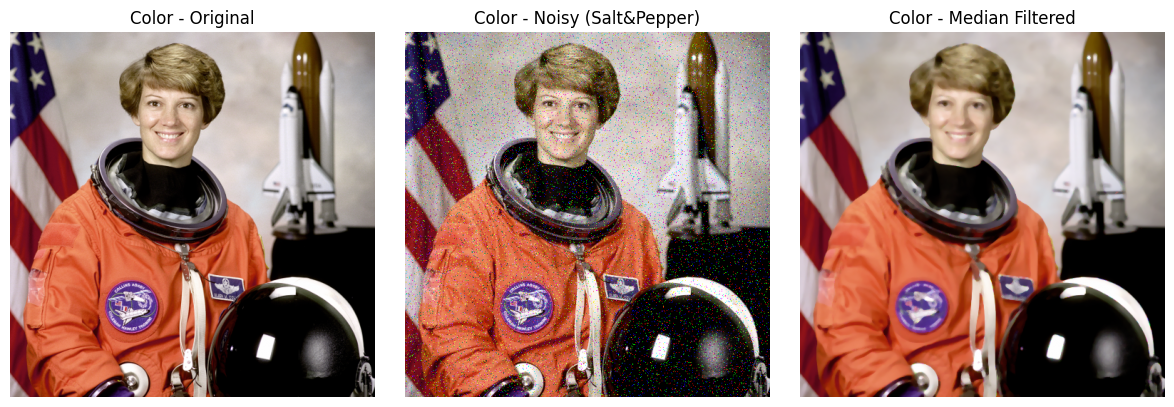

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# 1) FILTER MEDIAN PADA CITRA GRAYSCALE

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()	# grayscale, uint8
gray_float = img_as_float(gray_uint8) # konversi float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05) # amount=0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median
#	Kita gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 2) FILTER MEDIAN PADA CITRA BERWARNA

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()	# RGB, uint8
color_float = img_as_float(color_uint8) # rentang [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
#	Pada scikit-image 0.19+, median() mampu menangani array 3D (RGB),
#	atau kita bisa memanggil per kanal. Di sini langsung:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
	color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


PENUGASAN

## 3. Transformasi Logaritmik dan Gamma pada Citra Grayscale

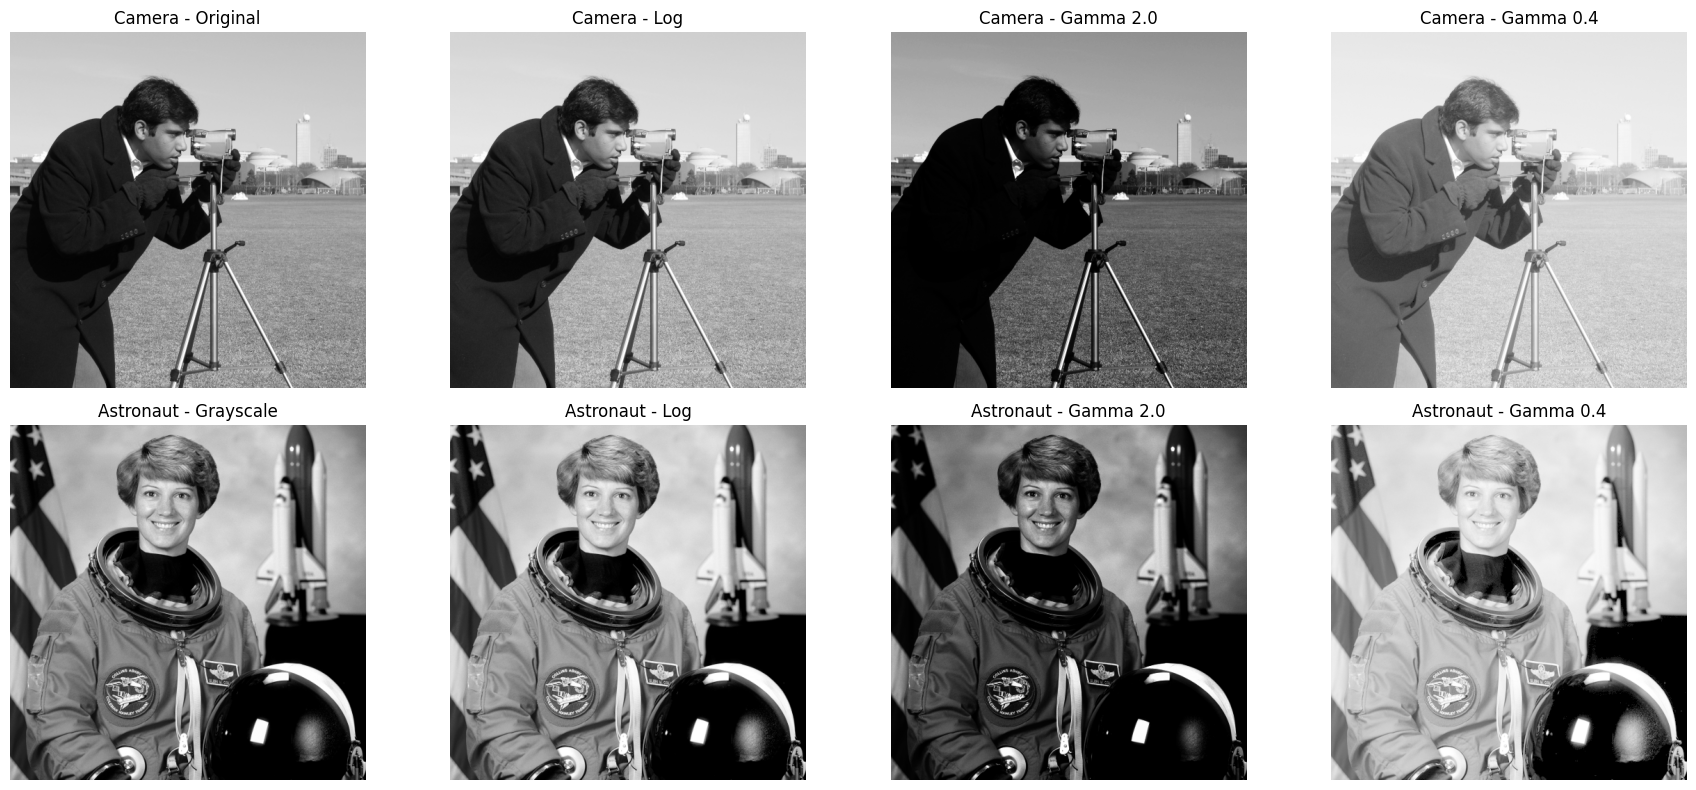

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# Ambil dan normalisasi dua citra
camera = img_as_float(data.camera())  # Sudah grayscale
astronaut = img_as_float(color.rgb2gray(data.astronaut()))  # Konversi ke grayscale

# Transformasi Logaritmik dan Gamma untuk camera
camera_log = exposure.adjust_log(camera, gain=1)
camera_gamma_dark = exposure.adjust_gamma(camera, gamma=2.0, gain=1)
camera_gamma_bright = exposure.adjust_gamma(camera, gamma=0.4, gain=1)

# Transformasi Logaritmik dan Gamma untuk astronaut
astro_log = exposure.adjust_log(astronaut, gain=1)
astro_gamma_dark = exposure.adjust_gamma(astronaut, gamma=2.0, gain=1)
astro_gamma_bright = exposure.adjust_gamma(astronaut, gamma=0.4, gain=1)

# Tampilkan perbandingan secara visual
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Baris 1: camera
axes[0, 0].imshow(camera, cmap='gray')
axes[0, 0].set_title("Camera - Original")
axes[0, 1].imshow(camera_log, cmap='gray')
axes[0, 1].set_title("Camera - Log")
axes[0, 2].imshow(camera_gamma_dark, cmap='gray')
axes[0, 2].set_title("Camera - Gamma 2.0")
axes[0, 3].imshow(camera_gamma_bright, cmap='gray')
axes[0, 3].set_title("Camera - Gamma 0.4")

# Baris 2: astronaut
axes[1, 0].imshow(astronaut, cmap='gray')
axes[1, 0].set_title("Astronaut - Grayscale")
axes[1, 1].imshow(astro_log, cmap='gray')
axes[1, 1].set_title("Astronaut - Log")
axes[1, 2].imshow(astro_gamma_dark, cmap='gray')
axes[1, 2].set_title("Astronaut - Gamma 2.0")
axes[1, 3].imshow(astro_gamma_bright, cmap='gray')
axes[1, 3].set_title("Astronaut - Gamma 0.4")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Perbandingan Contrast Stretching vs Histogram Equalization

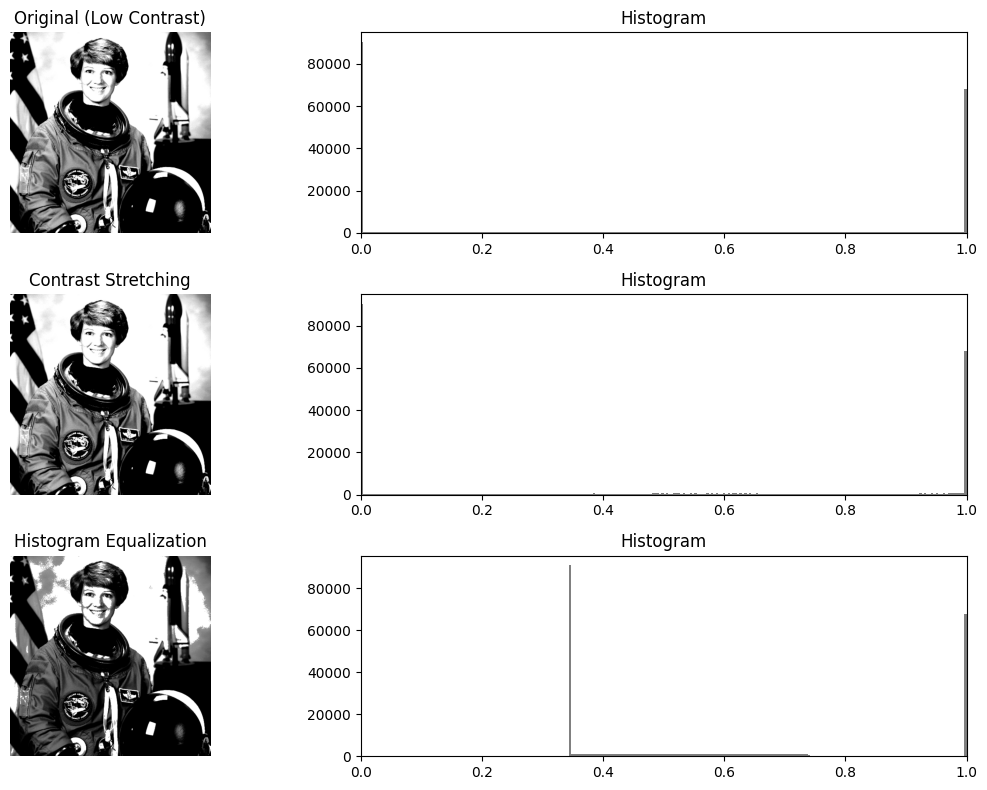

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# Ambil citra RGB dan ubah ke grayscale
astro_rgb = data.astronaut()
astro_gray = color.rgb2gray(astro_rgb)
astro_gray = img_as_float(astro_gray)  # Normalisasi ke [0, 1]

# Buat simulasi citra dengan kontras rendah
image_low_contrast = exposure.rescale_intensity(astro_gray, in_range=(0.3, 0.7))

# Metode 1: Contrast Stretching
contrast_stretched = exposure.rescale_intensity(image_low_contrast, in_range='image', out_range=(0, 1))

# Metode 2: Histogram Equalization
hist_equalized = exposure.equalize_hist(image_low_contrast)

# Visualisasi hasil dan histogramnya
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

titles = [
    "Original (Low Contrast)", "Histogram",
    "Contrast Stretching", "Histogram",
    "Histogram Equalization", "Histogram"
]

images = [
    image_low_contrast, image_low_contrast,
    contrast_stretched, contrast_stretched,
    hist_equalized, hist_equalized
]

for i in range(3):
    axes[i, 0].imshow(images[i * 2], cmap='gray')
    axes[i, 0].set_title(titles[i * 2])
    axes[i, 0].axis('off')

    axes[i, 1].hist(images[i * 2 + 1].ravel(), bins=256, range=(0, 1), color='gray')
    axes[i, 1].set_title(titles[i * 2 + 1])
    axes[i, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


## 5. Perbandingan Filter Median vs Rata-Rata untuk Salt-and-Pepper Noise

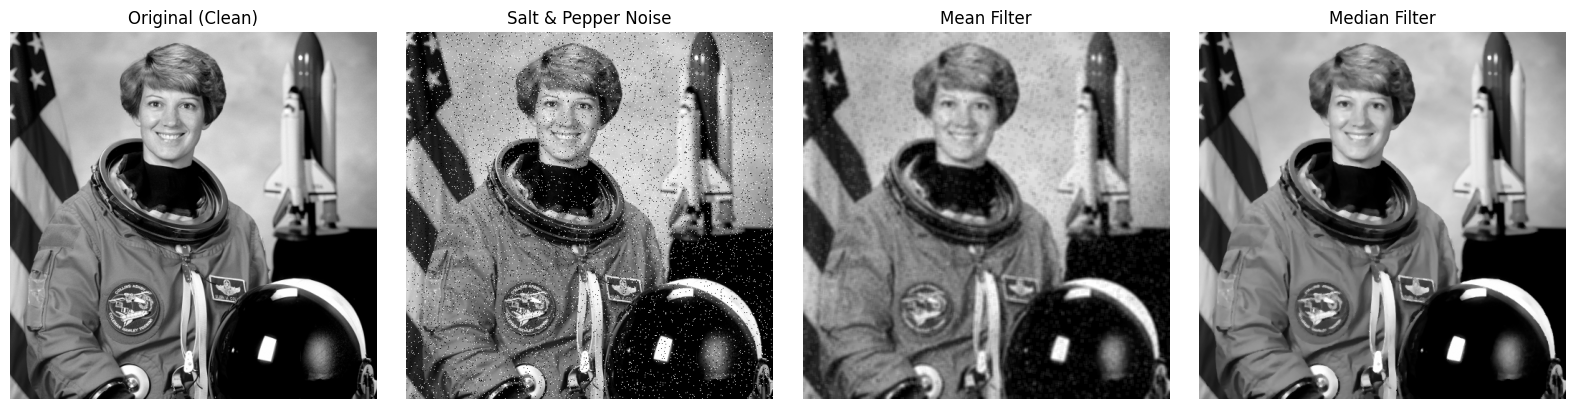

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, util, filters, morphology, img_as_float
from scipy.ndimage import convolve

# Ambil citra astronaut dan ubah ke grayscale
astro_rgb = data.astronaut()
astro_gray = img_as_float(color.rgb2gray(astro_rgb))

# Tambahkan noise salt-and-pepper
noisy_image = util.random_noise(astro_gray, mode='s&p', amount=0.05)

# Filter rata-rata (mean filter) dengan kernel 5x5
kernel = np.ones((5, 5)) / 25
mean_filtered = convolve(noisy_image, kernel)

# Filter median dengan structuring element berupa disk radius 2
median_filtered = filters.median(noisy_image, morphology.disk(2))

# Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Original (Clean)", "Salt & Pepper Noise", "Mean Filter", "Median Filter"]
images = [astro_gray, noisy_image, mean_filtered, median_filtered]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()
